In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split, KFold, cross_val_score, learning_curve
import seaborn as sns
from sklearn.metrics import (mean_squared_error, mean_absolute_error, 
                            r2_score, explained_variance_score)
from yellowbrick.regressor import (residuals_plot, prediction_error)
import shap
from sklearn.base import clone
from scipy import stats
import joblib

In [3]:
model = joblib.load("../../../../models/knn/knn_model_v1.joblib")

In [4]:
df = pd.read_csv('../../../../data/preprocessed/selected_features_dataset_V2.csv')

X = df.drop(['price_per_m2'], axis=1)
y = df['price_per_m2']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [5]:
X_train, X_val, y_train, y_val = train_test_split(X_train, y_train, test_size=0.2, random_state=42)


In [20]:
df.columns.tolist()

['address_locality',
 'address_line_2',
 'near_Koh_Pich_in_km',
 'near_Bassac_Lane_in_km',
 'near_Royal_Palace_in_km',
 'near_Phnom_Penh_Airport_in_km',
 'n_secondary_school_in_3km_to_5km',
 'n_primary_school_5km',
 'n_primary_school_in_3km_to_5km',
 'n_university_in_2km_to_3km',
 'n_university_in_3km_to_5km',
 'n_resturant_in_1km',
 'n_super_market_5km',
 'n_super_market_in_1km_to_2km',
 'n_bank_5km',
 'price_per_m2']

In [6]:
from sklearn.metrics import (
    r2_score, mean_squared_error, mean_absolute_error,
    explained_variance_score, mean_absolute_percentage_error
)
import numpy as np
import pandas as pd

def calculate_metrics(model, X_train, X_test, y_train, y_test):
    """Calculate regression metrics including MAPE and average prices (actual & predicted)"""
    y_pred_train = model.predict(X_train)
    y_pred_test = model.predict(X_test)
    
    metrics = {
        'Train R²': r2_score(y_train, y_pred_train),
        'Test R²': r2_score(y_test, y_pred_test),
        'Train RMSE': np.sqrt(mean_squared_error(y_train, y_pred_train)),
        'Test RMSE': np.sqrt(mean_squared_error(y_test, y_pred_test)),
        'Train MAE': mean_absolute_error(y_train, y_pred_train),
        'Test MAE': mean_absolute_error(y_test, y_pred_test),
        'Train MAPE (%)': mean_absolute_percentage_error(y_train, y_pred_train) * 100,
        'Test MAPE (%)': mean_absolute_percentage_error(y_test, y_pred_test) * 100,
        'Explained Variance': explained_variance_score(y_test, y_pred_test),
        'Train-Test R² Gap': abs(r2_score(y_train, y_pred_train) - r2_score(y_test, y_pred_test)),
        'Avg Actual Train Price': np.mean(y_train),
        'Avg Predicted Train Price': np.mean(y_pred_train),
        'Avg Actual Test Price': np.mean(y_test),
        'Avg Predicted Test Price': np.mean(y_pred_test)
    }
    
    return pd.DataFrame.from_dict(metrics, orient='index', columns=['Value'])

# Usage
metrics_df = calculate_metrics(model, X_train, X_test, y_train, y_test)
print(metrics_df)

                                 Value
Train R²                      0.885831
Test R²                       0.870395
Train RMSE                  601.551742
Test RMSE                   623.643050
Train MAE                   348.462552
Test MAE                    362.512355
Train MAPE (%)               40.853352
Test MAPE (%)                40.789283
Explained Variance            0.870820
Train-Test R² Gap             0.015436
Avg Actual Train Price     1573.736847
Avg Predicted Train Price  1577.650364
Avg Actual Test Price      1596.474432
Avg Predicted Test Price   1632.193743


In [ ]:
def evaluate_by_decoded_location(model, X_test, y_test, location_col='address_line_2', min_samples=3):
    """
    Evaluate model performance with decoded location names using provided encoding maps
    
    Parameters:
    model : Trained model
    X_test : Test features
    y_test : True target values
    location_col : Column name containing encoded location codes
    min_samples : Minimum samples required to evaluate a location
    
    Returns:
    DataFrame with metrics for each decoded location
    """
    # Your provided encoding maps
    encoding_maps = {
        'address_line_2': {
            'Bak Kaeng': 0, 'Boeng Kak Ti Muoy': 1, 'Boeng Kak Ti Pir': 2, 
            'Boeng Keng Kang Ti Bei': 3, 'Boeng Keng Kang Ti Muoy': 4, 
            'Boeng Keng Kang Ti Pir': 5, 'Boeng Proluet': 6, 'Boeng Reang': 7,
            'Boeng Salang': 8, 'Boeng Thum': 9, 'Boeng Trabaek': 10,
            'Boeng Tumpun': 11, 'Chak Angrae Kraom': 12, 'Chak Angrae Leu': 13,
            'Chakto Mukh': 14, 'Chaom Chau': 15, 'Chbar Ampov Ti Pir': 16,
            'Cheung Aek': 17, 'Chey Chummeah': 18, 'Chhbar Ampov Ti Muoy': 19,
            'Chrang Chamreh Ti Muoy': 20, 'Chrang Chamreh Ti Pir': 21,
            'Chrouy Changvar': 22, 'Dangkao': 23, 'Kakab': 24, 'Kamboul': 25,
            'Kantaok': 26, 'Kaoh Dach': 27, 'Kbal Kaoh': 28, 'Khmuonh': 29,
            'Kilomaetr Lekh Prammuoy': 30, 'Kong Noy': 31, 'Kouk Roka': 32,
            'Krang Pongro': 33, 'Krang Thnong': 34, 'Mittapheap': 35,
            'Monourom': 36, 'Nirouth': 37, 'Olympic': 38, 'Ou Ruessei Ti Bei': 39,
            'Ou Ruessei Ti Buon': 40, 'Ou Ruessei Ti Muoy': 41, 'Ou Ruessei Ti Pir': 42,
            'Ovlaok': 43, 'Phleung Chheh Roteh': 44, 'Phnom Penh Thmei': 45,
            'Phsar Chas': 46, 'Phsar Daeum Kor': 47, 'Phsar Daeum Thkov': 48,
            'Phsar Depou Ti Bei': 49, 'Phsar Depou Ti Muoy': 50, 'Phsar Depou Ti Pir': 51,
            'Phsar Kandal Ti Muoy': 52, 'Phsar Kandal Ti Pir': 53, 'Phsar Thmei Ti Bei': 54,
            'Phsar Thmei Ti Muoy': 55, 'Phsar Thmei Ti Pir': 56, 'Pong Tuek': 57,
            'Ponhea Pon': 58, 'Ponsang': 59, 'Prateah Lang': 60, 'Preaek Aeng': 61,
            'Preaek Kampues': 62, 'Preaek Lieb': 63, 'Preaek Phnov': 64, 'Preaek Pra': 65,
            'Preaek Ta Sek': 66, 'Preaek Thmei': 67, 'Prey Sa': 68, 'Prey Veaeng': 69,
            'Roluos': 70, 'Ruessei Kaev': 71, 'Sak Sampov': 72, 'Samraong': 73,
            'Samraong Kraom': 74, 'Snaor': 75, 'Spean Thma': 76, 'Srah Chak': 77,
            'Stueng Mean Chey': 78, 'Svay Pak': 79, 'Tien': 80, 'Tonle Basak': 81,
            'Trapeang Krasang': 82, "Tuek L'ak Ti Bei": 83, "Tuek L'ak Ti Muoy": 84,
            "Tuek L'ak Ti Pir": 85, 'Tuek Thla': 86, 'Tumnob Tuek': 87,
            'Tuol Sangke': 88, 'Tuol Svay Prey Ti Muoy': 89, 'Tuol Svay Prey Ti Pir': 90,
            'Tuol Tumpung Ti Muoy': 91, 'Tuol Tumpung Ti Pir': 92, 'Veal Sbov': 93,
            'Veal Vong': 94, 'Voat Phnum': 95
        }
    }
    
    # Create reverse mapping (code to name)
    reverse_map = {v: k for k, v in encoding_maps[location_col].items()}
    
    # Create a copy of the data
    X_test_copy = X_test.copy()
    X_test_copy['price_per_m2'] = y_test.values
    
    results = []
    locations = X_test_copy[location_col].unique()
    
    for loc in locations:
        loc_data = X_test_copy[X_test_copy[location_col] == loc]
        
        if len(loc_data) < min_samples:
            continue
            
        # Keep all original features (don't drop location_col)
        X_loc = loc_data.drop(['price_per_m2'], axis=1)
        y_loc = loc_data['price_per_m2']
        y_pred = model.predict(X_loc)
        
        # Decode the location name
        location_name = reverse_map.get(loc, f"Unknown (Code: {loc})")
        
        results.append({
            'Location Code': loc,
            'Location Name': location_name,
            'Samples': len(loc_data),
            'RMSE': np.sqrt(mean_squared_error(y_loc, y_pred)),
            'MAE': mean_absolute_error(y_loc, y_pred),
            'R²': r2_score(y_loc, y_pred),
            'Avg Actual Price': y_loc.mean(),
            'Avg Predicted Price': y_pred.mean(),
            'Price Difference': y_loc.mean() - y_pred.mean(),
            '% Difference': ((y_loc.mean() - y_pred.mean()) / y_loc.mean()) * 100
        })
    
    # Create and format DataFrame
    results_df = pd.DataFrame(results)
    results_df = results_df.sort_values('Samples', ascending=False)
    
    # Format numeric columns
    float_cols = ['RMSE', 'MAE', 'R²', 'Avg Actual Price', 
                 'Avg Predicted Price', 'Price Difference', '% Difference']
    results_df[float_cols] = results_df[float_cols].round(2)
    
    # Set display options
    pd.set_option('display.max_columns', None)
    pd.set_option('display.width', 1000)
    pd.set_option('display.float_format', '{:.2f}'.format)
    
    return results_df

location_metrics = evaluate_by_decoded_location(
    model, 
    X_test, 
    y_test,
    location_col='address_line_2'
)

# Display the results
print("Model Performance by Decoded Location:")
display(location_metrics)  # Show top 20 locations by sample size

Model Performance by Decoded Location:


,Location Code,Location Name,Samples,RMSE,MAE,R²,Avg Actual Price,Avg Predicted Price,Price Difference,% Difference
24,15.00,Chaom Chau,61,412.91,332.86,0.47,1568.93,1541.35,27.57,1.76
4,59.00,Ponsang,59,54.67,37.64,-0.14,140.83,144.79,-3.96,-2.81
19,28.00,Kbal Kaoh,52,126.56,109.99,0.59,330.30,318.02,12.28,3.72
61,78.00,Stueng Mean Chey,49,635.25,483.85,-0.63,3119.38,3029.99,89.40,2.87
28,45.00,Phnom Penh Thmei,48,607.91,503.22,-1.54,2958.78,2716.18,242.60,8.20
...,...,...,...,...,...,...,...,...,...,...
81,85.00,Tuek L'ak Ti Pir,4,1000.17,925.81,-18.73,2447.62,3373.43,-925.81,-37.82
82,38.00,Olympic,4,1209.03,956.88,-0.67,4857.76,4731.11,126.64,2.61
15,50.00,Phsar Depou Ti Muoy,4,913.15,839.79,-7.89,2599.92,3439.71,-839.79,-32.30
69,49.00,Phsar Depou Ti Bei,3,279.88,250.85,-43.45,3860.43,3683.27,177.16,4.59


In [18]:
def mean_absolute_percentage_error(y_true, y_pred):
    y_true, y_pred = np.array(y_true), np.array(y_pred)
    return np.mean(np.abs((y_true - y_pred) / np.clip(y_true, 1e-8, None))) * 100

def evaluate_by_location(X_raw, y_true, predictions_df, label_encoders, location_col='address_locality'):
    results = []

    for model_name in predictions_df.columns:
        df = X_raw.copy()
        df['y_true'] = y_true
        df['y_pred'] = predictions_df[model_name]
        df['abs_error'] = np.abs(df['y_true'] - df['y_pred'])
        df['squared_error'] = (df['y_true'] - df['y_pred']) ** 2
        df['abs_pct_error'] = np.abs((df['y_true'] - df['y_pred']) / np.clip(df['y_true'], 1e-8, None)) * 100

        # Decode the encoded location column using the corresponding label encoder
        if location_col in label_encoders:
            encoder = label_encoders[location_col]
            df[location_col] = encoder.inverse_transform(df[location_col])

        grouped = df.groupby(location_col).agg(
            count=('y_true', 'size'),
            MAE=('abs_error', 'mean'),
            MSE=('squared_error', 'mean'),
            RMSE=('squared_error', lambda x: np.sqrt(np.mean(x))),
            MAPE=('abs_pct_error', 'mean')
        ).reset_index()

        grouped['Model'] = model_name
        results.append(grouped)

    return pd.concat(results, ignore_index=True)


In [15]:
LABEL_ENCODERS_PATH = "../../../../data/processed/label_encoders_v2.pkl"
label_encoders = joblib.load(LABEL_ENCODERS_PATH)


In [16]:
y_pred_test = model.predict(X_test)


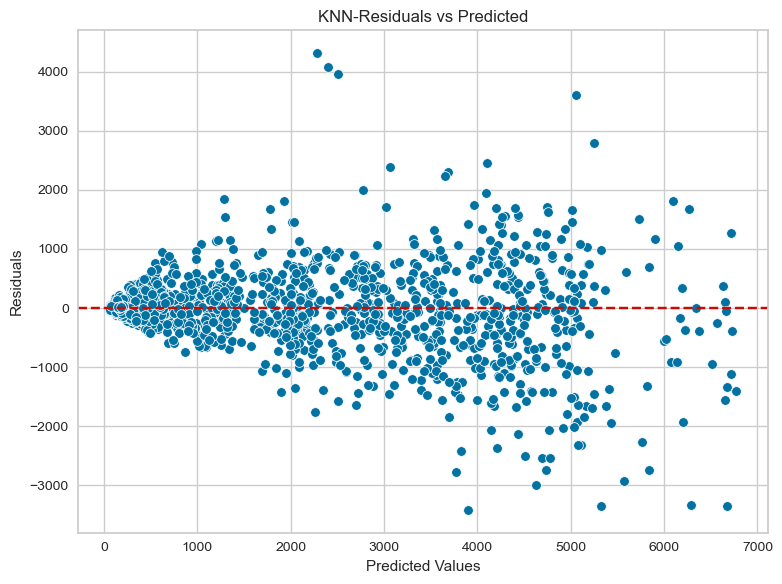

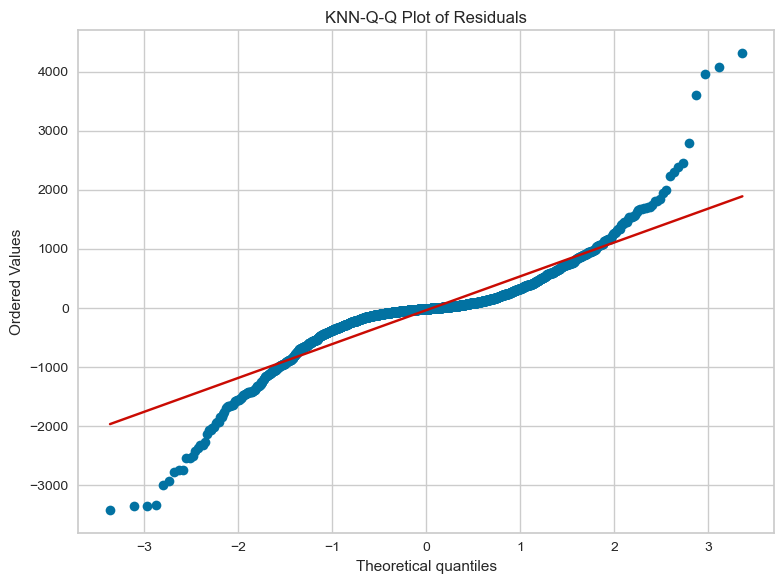

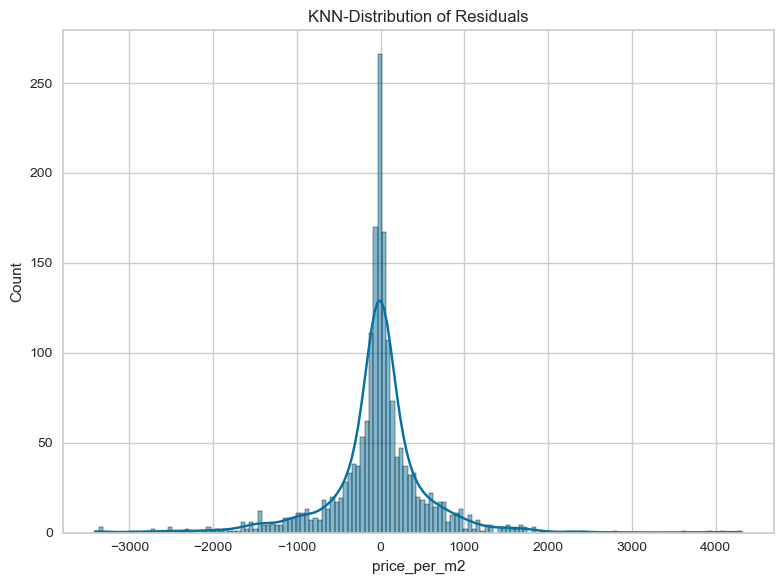

In [8]:
def plot_residuals_one_by_one(model, X_train, X_test, y_train, y_test):
    """Generate residual diagnostic plots, showing them one by one."""
    y_pred_test = model.predict(X_test)
    residuals = y_test - y_pred_test

    # Plot 1: Residuals vs Predicted
    plt.figure(figsize=(8, 6)) # Create a new figure for each plot
    sns.scatterplot(x=y_pred_test, y=residuals)
    plt.axhline(y=0, color='r', linestyle='--')
    plt.title('KNN-Residuals vs Predicted')
    plt.xlabel('Predicted Values')
    plt.ylabel('Residuals')
    plt.tight_layout()
    plt.show()

    # Plot 2: Q-Q Plot
    plt.figure(figsize=(8, 6))
    stats.probplot(residuals, plot=plt) # Pass plt directly for the current figure
    plt.title('KNN-Q-Q Plot of Residuals')
    plt.tight_layout()
    plt.show()

    # Plot 3: Residual Distribution
    plt.figure(figsize=(8, 6))
    sns.histplot(residuals, kde=True)
    plt.title('KNN-Distribution of Residuals')
    plt.tight_layout()
    plt.show()

# To use this, you would call:
plot_residuals_one_by_one(model, X_train, X_test, y_train, y_test)

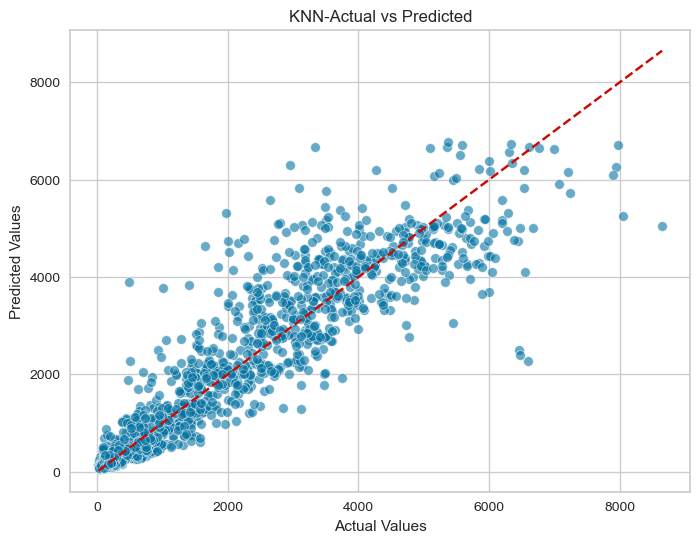

In [9]:
# 4. Actual vs Predicted Plot
def plot_actual_vs_predicted(y_true, y_pred):
    """Scatter plot of actual vs predicted values"""
    plt.figure(figsize=(8, 6))
    sns.scatterplot(x=y_true, y=y_pred, alpha=0.6)
    plt.plot([y_true.min(), y_true.max()], 
             [y_true.min(), y_true.max()], 'r--')
    plt.title('KNN-Actual vs Predicted')
    plt.xlabel('Actual Values')
    plt.ylabel('Predicted Values')
    plt.grid(True)
    plt.show()

y_pred_test = model.predict(X_test)
plot_actual_vs_predicted(y_test, y_pred_test)

In [10]:
# def plot_shap_summary(model, X, sample_size=100):
#     """Generate SHAP summary plot (using a sample for efficiency)"""
#     X_sample = X.sample(sample_size, random_state=42)
    
#     # For KNN, we'll use KernelExplainer
#     explainer = shap.KernelExplainer(model.predict, X_sample)
#     shap_values = explainer.shap_values(X_sample)
    
#     plt.figure()
#     shap.summary_plot(shap_values, X_sample, feature_names=X.columns, plot_type="bar")
#     plt.tight_layout()
#     plt.show()
    
#     plt.figure()
#     shap.summary_plot(shap_values, X_sample, feature_names=X.columns)
#     plt.tight_layout()
#     plt.show()
    
# plot_shap_summary(model, X_test)

d:\anaconda\envs\env_v3.10\lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but KNeighborsRegressor was fitted with feature names
  warnings.warn(


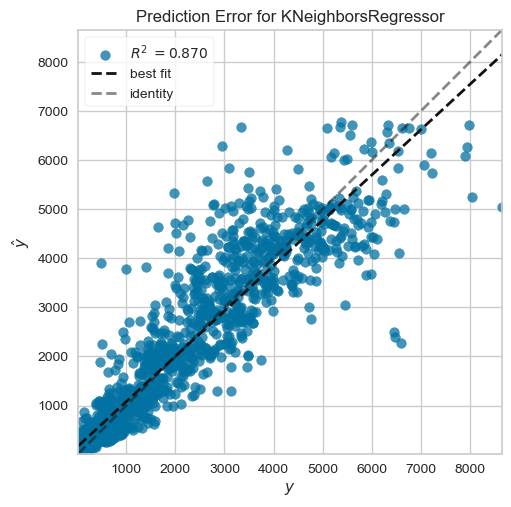

In [11]:
def plot_prediction_error(model, X_train, y_train, X_test, y_test):
    """Visualize prediction error with 45-degree line"""
    visualizer = prediction_error(
        model, X_train, y_train, X_test, y_test,
        bestfit=True, identity=True
    )
    visualizer.show()

plot_prediction_error(model, X_train, y_train, X_test, y_test)

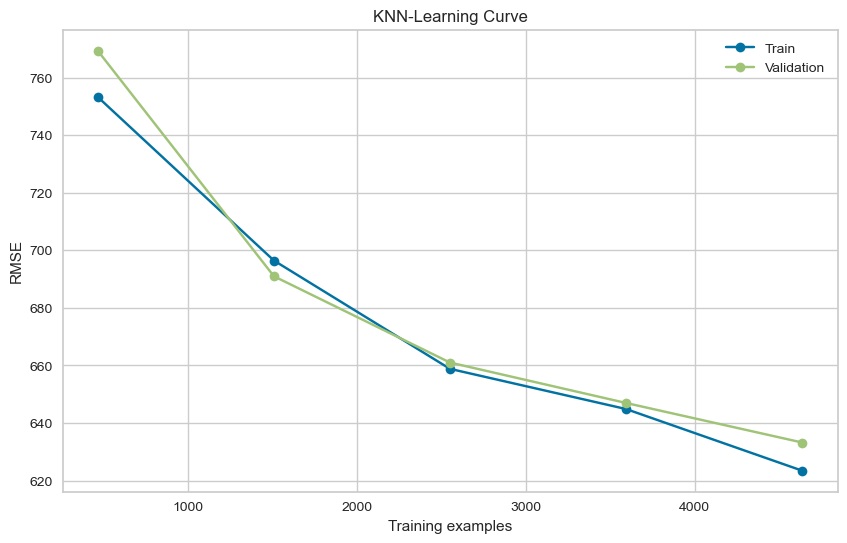

In [12]:
def plot_learning_curve(estimator, X, y):
    """Plot learning curve showing training and validation scores"""
    train_sizes, train_scores, test_scores = learning_curve(
        estimator, X, y, cv=5, n_jobs=-1,
        train_sizes=np.linspace(0.1, 1.0, 5),
        scoring='neg_root_mean_squared_error'
    )
    
    plt.figure(figsize=(10, 6))
    plt.plot(train_sizes, -train_scores.mean(1), 'o-', label='Train')
    plt.plot(train_sizes, -test_scores.mean(1), 'o-', label='Validation')
    plt.xlabel('Training examples')
    plt.ylabel('RMSE')
    plt.title('KNN-Learning Curve')
    plt.legend()
    plt.grid(True)
    plt.show()

plot_learning_curve(model, X_train, y_train)

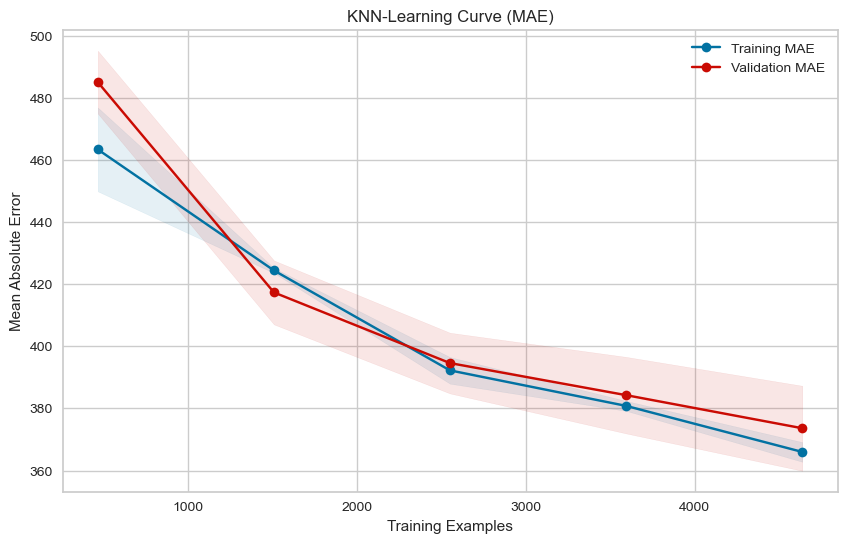

In [13]:
def plot_mae_learning_curve(estimator, X, y, cv=5, train_sizes=np.linspace(0.1, 1.0, 5)):
    """Generate MAE-based learning curve"""
    train_sizes, train_scores, val_scores = learning_curve(
        estimator=estimator,
        X=X,
        y=y,
        cv=cv,
        n_jobs=-1,
        train_sizes=train_sizes,
        scoring='neg_mean_absolute_error'
    )
    
    train_mae = -train_scores
    val_mae = -val_scores
    
    plt.figure(figsize=(10, 6))
    plt.plot(train_sizes, train_mae.mean(axis=1), 'o-', color='b', label='Training MAE')
    plt.plot(train_sizes, val_mae.mean(axis=1), 'o-', color='r', label='Validation MAE')
    
    plt.title('KNN-Learning Curve (MAE)')
    plt.xlabel('Training Examples')
    plt.ylabel('Mean Absolute Error')
    plt.legend()
    plt.grid(True)
    
    plt.fill_between(train_sizes, 
                    train_mae.mean(axis=1) - train_mae.std(axis=1),
                    train_mae.mean(axis=1) + train_mae.std(axis=1),
                    alpha=0.1, color='b')
    
    plt.fill_between(train_sizes,
                    val_mae.mean(axis=1) - val_mae.std(axis=1),
                    val_mae.mean(axis=1) + val_mae.std(axis=1),
                    alpha=0.1, color='r')
    
    plt.show()

plot_mae_learning_curve(model, X_train, y_train)

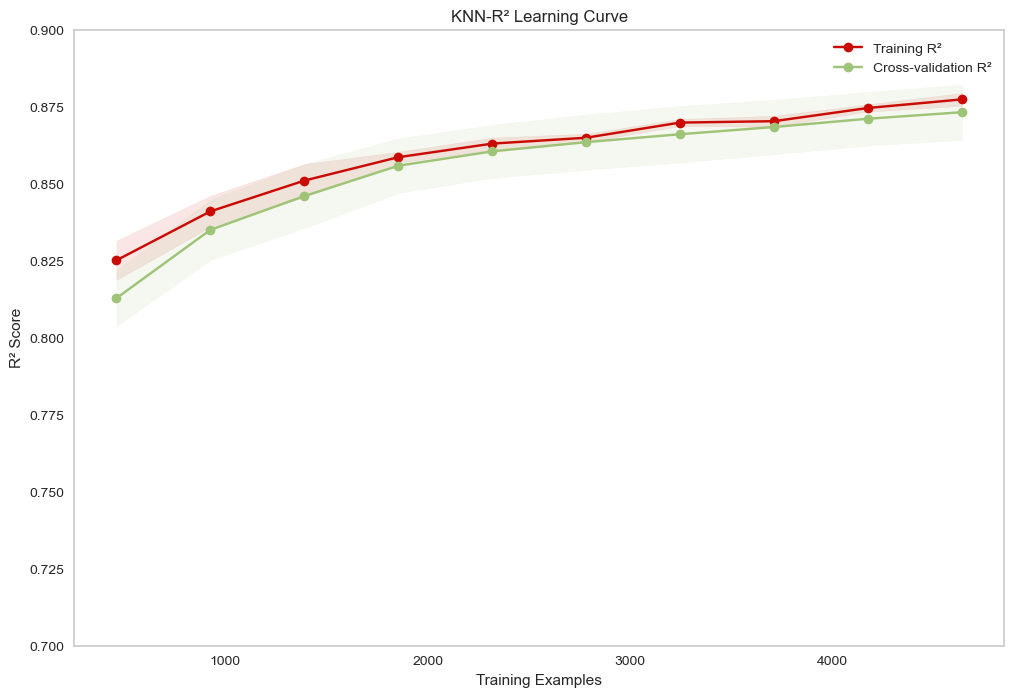

In [14]:
def plot_r2_learning_curve(estimator, X, y, cv=5, train_sizes=np.linspace(0.1, 1.0, 10)):
    """Generate R² learning curve with confidence intervals"""
    train_sizes, train_scores, test_scores = learning_curve(
        estimator=estimator,
        X=X,
        y=y,
        cv=cv,
        n_jobs=-1,
        train_sizes=train_sizes,
        scoring='r2'
    )
    
    train_scores_mean = np.mean(train_scores, axis=1)
    train_scores_std = np.std(train_scores, axis=1)
    test_scores_mean = np.mean(test_scores, axis=1)
    test_scores_std = np.std(test_scores, axis=1)
    
    plt.figure(figsize=(12, 8))
    plt.title("KNN-R² Learning Curve")
    plt.xlabel("Training Examples")
    plt.ylabel("R² Score")
    plt.ylim(0.7, 0.9)
    
    plt.fill_between(train_sizes, 
                    train_scores_mean - train_scores_std,
                    train_scores_mean + train_scores_std,
                    alpha=0.1, color="r")
    plt.fill_between(train_sizes, 
                    test_scores_mean - test_scores_std,
                    test_scores_mean + test_scores_std,
                    alpha=0.1, color="g")
    
    plt.plot(train_sizes, train_scores_mean, 'o-', color="r", label="Training R²")
    plt.plot(train_sizes, test_scores_mean, 'o-', color="g", label="Cross-validation R²")
    
    plt.legend(loc="best")
    plt.grid()
    plt.show()

plot_r2_learning_curve(model, X_train, y_train)